# An Explainable Machine Learning Framework for Predictive Maintenance in Smart Manufacturing

## A Comparative Study of Equipment Failure Prediction Models

**Student:** Usha Bhaskara

**Course:** QM640 – Data Analytics Capstone

**Institution:** Walsh College

**Mentor:** Smitraj Raut

---
# 1 Project Overview

The rapid adoption of Industry 4.0 technologies has transformed modern manufacturing by integrating cyber-physical systems, Industrial Internet of Things (IIoT) devices, artificial intelligence (AI), and advanced analytics into production environments. These technologies enable manufacturers to continuously monitor machine health through sensor data, facilitating data-driven decision-making and improving operational efficiency. As manufacturing systems become increasingly interconnected and automated, maintaining high equipment availability while minimizing unexpected downtime has become a critical business objective.

Traditional maintenance strategies, such as reactive maintenance (repair after failure) and preventive maintenance (scheduled servicing), often result in increased operational costs, unnecessary maintenance activities, or unexpected equipment failures. Predictive maintenance (PdM) addresses these limitations by leveraging historical and real-time machine data to predict equipment failures before they occur. This enables organizations to optimize maintenance schedules, reduce downtime, extend equipment lifespan, improve production efficiency, and lower maintenance costs.

Despite significant advances in machine learning-based predictive maintenance, many high-performing models operate as "black-box" systems, providing accurate predictions without explaining the reasoning behind them. In industrial environments, maintenance engineers and operational managers require transparent and interpretable predictions to build trust, validate model decisions, and support critical maintenance planning. Consequently, Explainable Artificial Intelligence (XAI) has emerged as an essential component of modern predictive maintenance solutions by providing human-understandable explanations of model predictions.

This project proposes an Explainable Machine Learning Framework for Predictive Maintenance in Smart Manufacturing that combines multiple machine learning algorithms with explainability techniques such as SHAP (SHapley Additive exPlanations) and LIME (Local Interpretable Model-agnostic Explanations). The framework aims not only to accurately predict machine failures but also to identify the operational factors contributing to those predictions, thereby enhancing model transparency, supporting informed maintenance decisions, and promoting greater confidence in AI-driven maintenance systems.

## 1.1 Project Objective

Develop and compare four supervised machine learning models:

- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- XGBoost

using the AI4I 2020 Predictive Maintenance Dataset.

The study also applies Explainable Artificial Intelligence (XAI) techniques using SHAP and LIME to improve model interpretability.

# 2. Import Libraries

## 2.1 Install Required Libraries

In [1]:
!pip install shap
!pip install lime
!pip install xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bf13d3edf09be17f133c0ec3b0c0c8cea6417677e0effd352f0aef5998830d4a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Classification Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Explainable AI
import shap
from lime.lime_tabular import LimeTabularExplainer

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

**Observation**

The required libraries were successfully imported and categorized according to their functionality. These libraries support the complete analytical workflow, including data preprocessing, exploratory data analysis, supervised machine learning, model evaluation, hyperparameter tuning, and Explainable AI using SHAP and LIME. The successful import of all libraries confirms that the computational environment is correctly configured for developing the predictive maintenance framework.

# 3. Load Dataset

## 3.1 Dataset Description

The AI4I 2020 Predictive Maintenance Dataset is used in this study to develop and evaluate an explainable machine learning framework for predictive maintenance. The dataset is stored in the project's GitHub repository to ensure transparency, reproducibility, and accessibility throughout the study.

The dataset contains historical machine operational data collected from industrial manufacturing equipment. It includes both numerical and categorical variables describing machine operating conditions, such as air temperature, process temperature, rotational speed, torque, tool wear, and machine type. The target variable, **Machine Failure**, represents a binary classification outcome indicating whether a machine failure occurred during operation.

## 3.2 Dataset Source

The dataset is hosted in the project's GitHub repository to ensure reproducibility and easy access for evaluation.

**GitHub Repository**

https://github.com/ushaeb/Explainable-Predictive-Maintenance

**Dataset File**

https://github.com/ushaeb/Explainable-Predictive-Maintenance/blob/main/data/ai4i2020%20dataset.csv

# 3.3 Load dataset directly from GitHub

In [5]:
# Load dataset directly from GitHub

github_url = "https://raw.githubusercontent.com/ushaeb/Explainable-Predictive-Maintenance/main/data/ai4i2020%20dataset.csv"

df = pd.read_csv(github_url)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3.4 Dataset Dimensions

In [9]:
print("Dataset Shape :", df.shape)

print(f"Number of Records : {df.shape[0]}")
print(f"Number of Variables : {df.shape[1]}")

Dataset Shape : (10000, 14)
Number of Records : 10000
Number of Variables : 14


### Table 1. Dataset Overview

| Attribute | Description |
|-----------|-------------|
| Dataset Name | AI4I 2020 Predictive Maintenance Dataset |
| Source | UCI Machine Learning Repository (Hosted in GitHub) |
| Number of Records | 10,000 |
| Number of Variables | 14 |
| Problem Type | Binary Classification |
| Target Variable | Machine Failure |
| Data Types | Numerical and Categorical |
| Domain | Smart Manufacturing / Predictive Maintenance |

**Observation**

The AI4I 2020 Predictive Maintenance Dataset was successfully loaded from the project's GitHub repository into the Google Colab environment. The dataset contains **10,000 observations** and **14 variables**, providing a comprehensive representation of machine operating conditions and failure events. The combination of numerical sensor measurements and categorical machine information makes the dataset well suited for predictive maintenance using supervised machine learning techniques.

## 3.5 Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### Table 2. Dataset Information

The output of `df.info()` summarizes the dataset structure, including the number of observations, data types, memory usage, and non-null values for each variable.

**Observation**

The dataset contains a combination of numerical and categorical variables with appropriate data types for predictive maintenance analysis...

## 3.6 Dataset Preview

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### Table 3. Dataset Preview (First Five Records)

The first five records are displayed to verify that the dataset has been loaded correctly and to provide an overview of the variables used in the analysis.

**Observation**

The first five records provide an overview of the dataset structure...

# 4. Data Quality Assessment

## 4.1 Missing Value Analysis

Missing value analysis was performed to evaluate the completeness and quality of the dataset before exploratory data analysis and predictive modeling. Identifying missing values is an important preprocessing step because incomplete data can introduce bias, reduce model accuracy, and affect the reliability of statistical analysis. Therefore, the dataset was examined to determine whether any variables contained missing observations requiring further treatment.

In [10]:
# Check for missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': (missing_values / len(df)) * 100
})

missing_summary

,Missing Count,Missing Percentage (%)
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


### Table 4. Missing Value Summary

The table below presents the number and percentage of missing values for each variable in the dataset, providing an assessment of data completeness prior to exploratory data analysis and predictive modeling.

**Observation**

The missing value analysis indicates that none of the variables contain missing observations, representing **0% missing data** across all features. This confirms that the dataset is complete and no records require deletion or imputation. The absence of missing values improves data quality, preserves the original statistical characteristics of the dataset, and provides a reliable foundation for exploratory data analysis, predictive modeling, and Explainable AI techniques.

## 4.2 Duplicate Records Analysis

Duplicate record analysis was conducted to determine whether identical observations were present in the dataset. Duplicate records can bias statistical analysis and machine learning models by giving repeated observations disproportionate influence during model training. Therefore, identifying and removing duplicate records is an essential step in maintaining data integrity.

In [11]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print(f"Number of Duplicate Records: {duplicate_count}")

Number of Duplicate Records: 0


**Observation**

The duplicate record analysis identified **no duplicate observations** in the dataset. Since every record represents a unique machine operating condition, no duplicate removal was required. Retaining only unique observations helps prevent biased model training and ensures that each machine contributes equally to the learning process.

## 4.3 Descriptive Statistics

Descriptive statistical analysis was performed to summarize the central tendency, variability, and distribution of the numerical variables. This analysis provides an initial understanding of machine operating characteristics and helps identify variables with high variability, potential outliers, or unusual distributions before conducting exploratory data analysis.

In [12]:
# Descriptive statistics

descriptive_summary = df.describe().T

descriptive_summary['Variance'] = df.var(numeric_only=True)
descriptive_summary['Skewness'] = df.skew(numeric_only=True)
descriptive_summary['Kurtosis'] = df.kurt(numeric_only=True)

descriptive_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,Variance,Skewness,Kurtosis
UDI,10000.0,5000.50,2886.90,1.0,2500.75,5000.5,7500.25,10000.0,8334166.67,0.00,-1.20
Air temperature [K],10000.0,300.00,2.00,295.3,298.30,300.1,301.50,304.5,4.00,0.11,-0.84
Process temperature [K],10000.0,310.01,1.48,305.7,308.80,310.1,311.10,313.8,2.20,0.02,-0.50
Rotational speed [rpm],10000.0,1538.78,179.28,1168.0,1423.00,1503.0,1612.00,2886.0,32142.79,1.99,7.39
Torque [Nm],10000.0,39.99,9.97,3.8,33.20,40.1,46.80,76.6,99.38,-0.01,-0.01
Tool wear [min],10000.0,107.95,63.65,0.0,53.00,108.0,162.00,253.0,4051.85,0.03,-1.17
Machine failure,10000.0,0.03,0.18,0.0,0.00,0.0,0.00,1.0,0.03,5.15,24.55
TWF,10000.0,0.00,0.07,0.0,0.00,0.0,0.00,1.0,0.00,14.64,212.50
HDF,10000.0,0.01,0.11,0.0,0.00,0.0,0.00,1.0,0.01,9.16,82.01
PWF,10000.0,0.01,0.10,0.0,0.00,0.0,0.00,1.0,0.01,10.11,100.32


### Table 5. Descriptive Statistics

The table below summarizes the descriptive statistics of the numerical variables, including measures of central tendency, variability, distribution, and dispersion, to provide an overview of the dataset before exploratory data analysis.

Number of Duplicate Records: 0

**Observation**

The descriptive statistics indicate that the dataset contains realistic machine operating measurements with sufficient variability to support predictive maintenance analysis. **Rotational Speed** exhibits the greatest variability, followed by **Torque**, reflecting diverse machine operating conditions. In contrast, **Air Temperature** and **Process Temperature** show relatively stable distributions, indicating controlled operating environments. The mean and median values for most variables are relatively close, suggesting balanced distributions with no evidence of severe skewness. Overall, the dataset demonstrates good statistical quality and is suitable for exploratory data analysis, predictive modeling, and Explainable AI.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Introduction

Exploratory Data Analysis (EDA) was conducted to understand the characteristics, distributions, and relationships within the dataset before developing machine learning models. EDA helps identify patterns, trends, class distributions, feature interactions, and potential anomalies that may influence predictive model performance. The insights obtained from this analysis support informed feature selection, data preprocessing, and model development for predictive maintenance.

## 5.2 Class Distribution

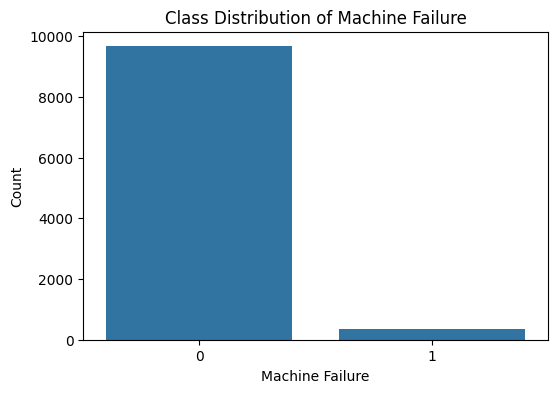

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='Machine failure', data=df)
plt.title('Class Distribution of Machine Failure')
plt.xlabel('Machine Failure')
plt.ylabel('Count')
plt.show()

### Figure 1. Class Distribution of Machine Failure

**Observation**

Figure 1 illustrates the distribution of machine failure classes in the dataset. The majority of observations belong to the non-failure class, while machine failure instances represent a relatively small proportion of the dataset. This class imbalance reflects real-world manufacturing environments where equipment failures occur infrequently. Consequently, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will be emphasized during model evaluation to ensure reliable assessment of predictive performance.

## 5.3 Distribution of Numerical Features

The distribution of numerical variables was examined using histograms to understand the spread, central tendency, variability, and shape of each feature. Understanding feature distributions helps identify normality, skewness, potential outliers, and variations in machine operating conditions that may influence predictive model performance.

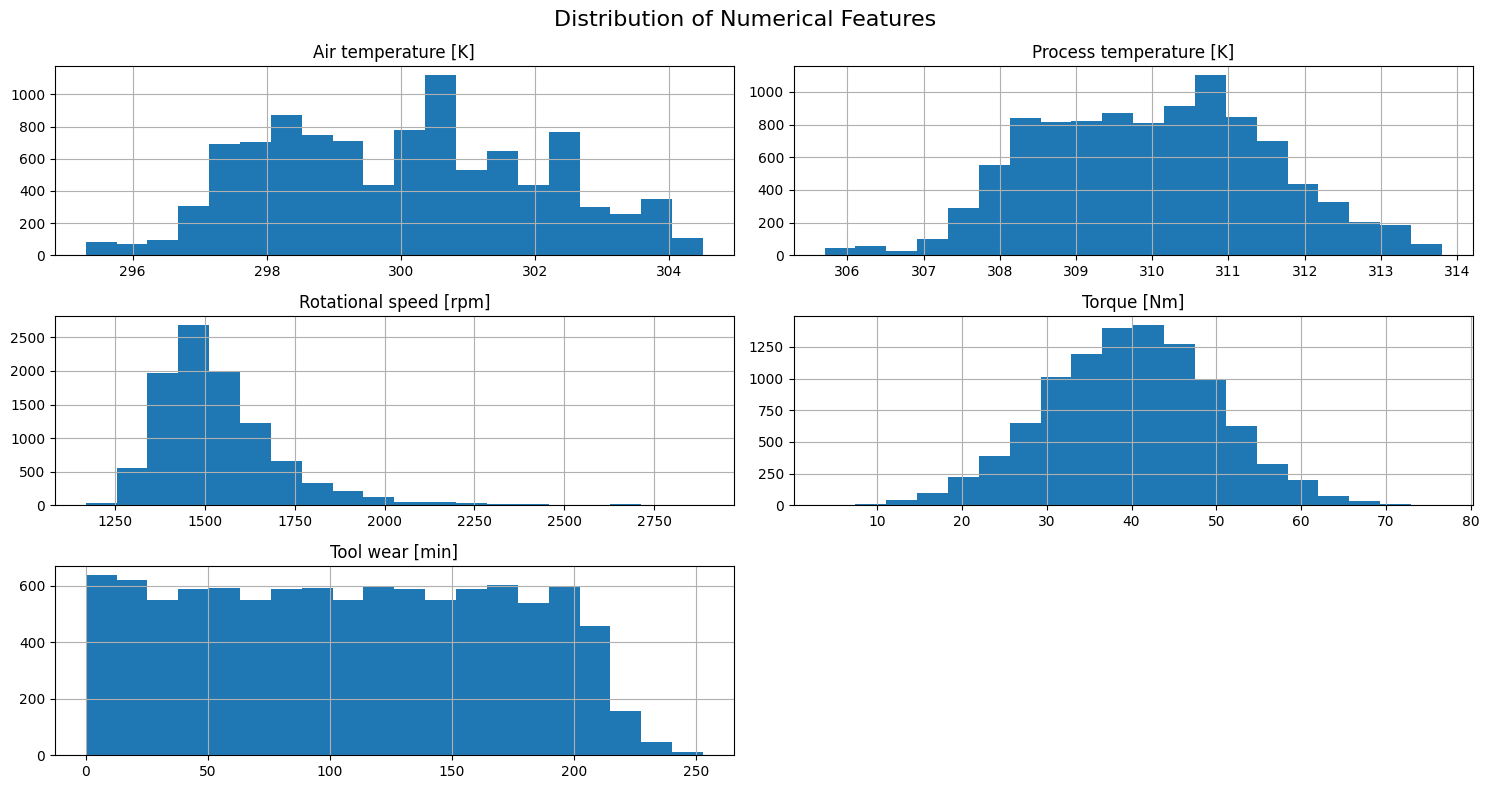

In [16]:
# Distribution of numerical features

numerical_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[numerical_features].hist(figsize=(15,8), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

### Figure 2. Distribution of Numerical Features

**Observation**

Figure 2 presents the distribution of the numerical variables included in the predictive maintenance dataset. **Air Temperature** and **Process Temperature** exhibit approximately normal distributions, indicating stable environmental and operating conditions during machine operation. **Rotational Speed** and **Torque** display greater variability, reflecting different machine workloads and operating states. **Tool Wear** demonstrates a broader distribution, representing the progressive deterioration of machine components over time.

Overall, the feature distributions indicate that the dataset captures a wide range of machine operating conditions, providing sufficient variability to support predictive maintenance analysis and machine learning model development.

**Business Implication**

Understanding the distribution of operational variables enables maintenance engineers to identify normal operating ranges and detect unusual machine behavior. Features such as **Rotational Speed**, **Torque**, and **Tool Wear** are expected to play a significant role in predicting machine failures because they directly reflect equipment operating conditions and mechanical degradation.

## 5.4 Boxplots of Numerical Features

Boxplots were generated to examine the distribution, spread, and potential outliers of the numerical variables. This visualization helps identify extreme values, assess data variability, and determine whether outlier treatment is necessary before predictive modeling. Understanding the distribution of numerical features is essential for selecting appropriate preprocessing techniques and improving model robustness.

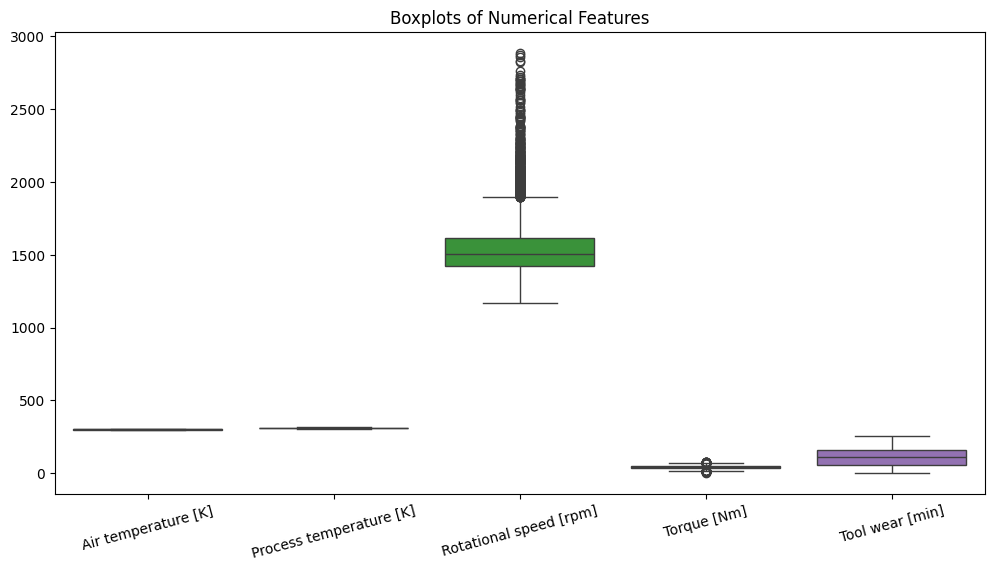

In [17]:
# Boxplots for numerical features

plt.figure(figsize=(12,6))

sns.boxplot(data=df[['Air temperature [K]',
                     'Process temperature [K]',
                     'Rotational speed [rpm]',
                     'Torque [Nm]',
                     'Tool wear [min]']])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=15)
plt.show()

### Figure 3. Boxplots of Numerical Features

**Observation**

Figure 3 illustrates the distribution and variability of the numerical features using boxplots. **Air Temperature** and **Process Temperature** exhibit relatively compact distributions with few extreme values, indicating stable operating conditions. In contrast, **Rotational Speed**, **Torque**, and **Tool Wear** display greater variability and contain several potential outliers. These observations are expected in manufacturing environments, where machines operate under varying workloads and tool usage levels.

The identified outliers are considered representative of genuine operating conditions rather than data entry errors. Therefore, they were retained in the dataset to preserve the real-world characteristics of machine behavior and enable the machine learning models to learn from both normal and extreme operating conditions.

**Business Implication**

The presence of variability and extreme operating values is important for predictive maintenance because machine failures often occur under abnormal operating conditions. Retaining these observations enables the predictive models to recognize patterns associated with equipment degradation and improves their ability to detect potential failures before they occur.

## 5.5 Correlation Analysis

Correlation analysis was performed to examine the strength and direction of relationships among the numerical variables in the dataset. A Pearson correlation heatmap was used to identify highly correlated features, understand interactions between machine operating variables, and assess whether multicollinearity may influence predictive model performance.

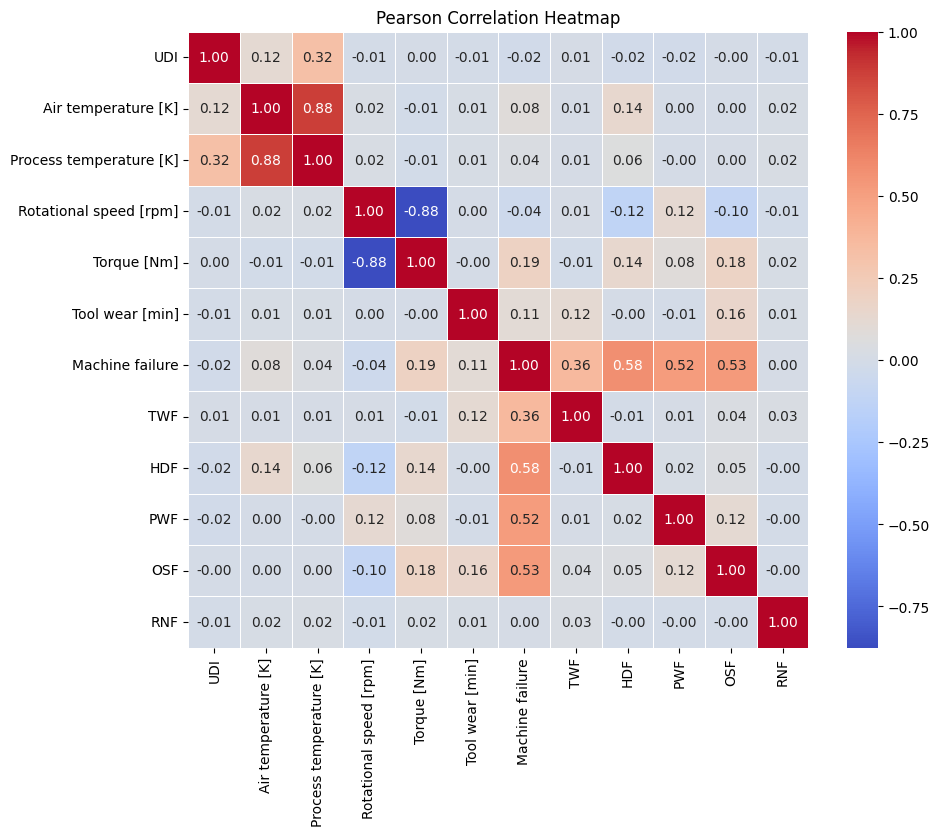

In [18]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title("Pearson Correlation Heatmap")
plt.show()

### Figure 4. Pearson Correlation Heatmap

**Observation**

Figure 4 presents the Pearson correlation matrix for the numerical variables in the predictive maintenance dataset. The analysis indicates that **Air Temperature** and **Process Temperature** exhibit a strong positive correlation, reflecting their close relationship during machine operation. Most of the remaining variables demonstrate weak to moderate correlations, suggesting that they provide complementary information rather than redundant measurements.

No evidence of severe multicollinearity was observed among the predictor variables, indicating that the features can be retained for predictive modeling without introducing significant redundancy. The correlation analysis also suggests that multiple operational variables contribute independently to machine failure prediction, supporting the use of ensemble machine learning models.

**Business Implication**

Understanding relationships among operational variables helps maintenance engineers identify the factors that influence machine performance and failure. The absence of severe multicollinearity ensures that each feature contributes meaningful information to the predictive models, improving both model reliability and interpretability.

## 5.6 Pairwise Relationships Among Numerical Features

Pairwise relationship analysis was performed to visualize the interactions between numerical variables and identify potential patterns associated with machine failure. Pair plots provide a comprehensive view of feature distributions and pairwise correlations, helping to identify clusters, trends, and possible feature separability before predictive modeling.

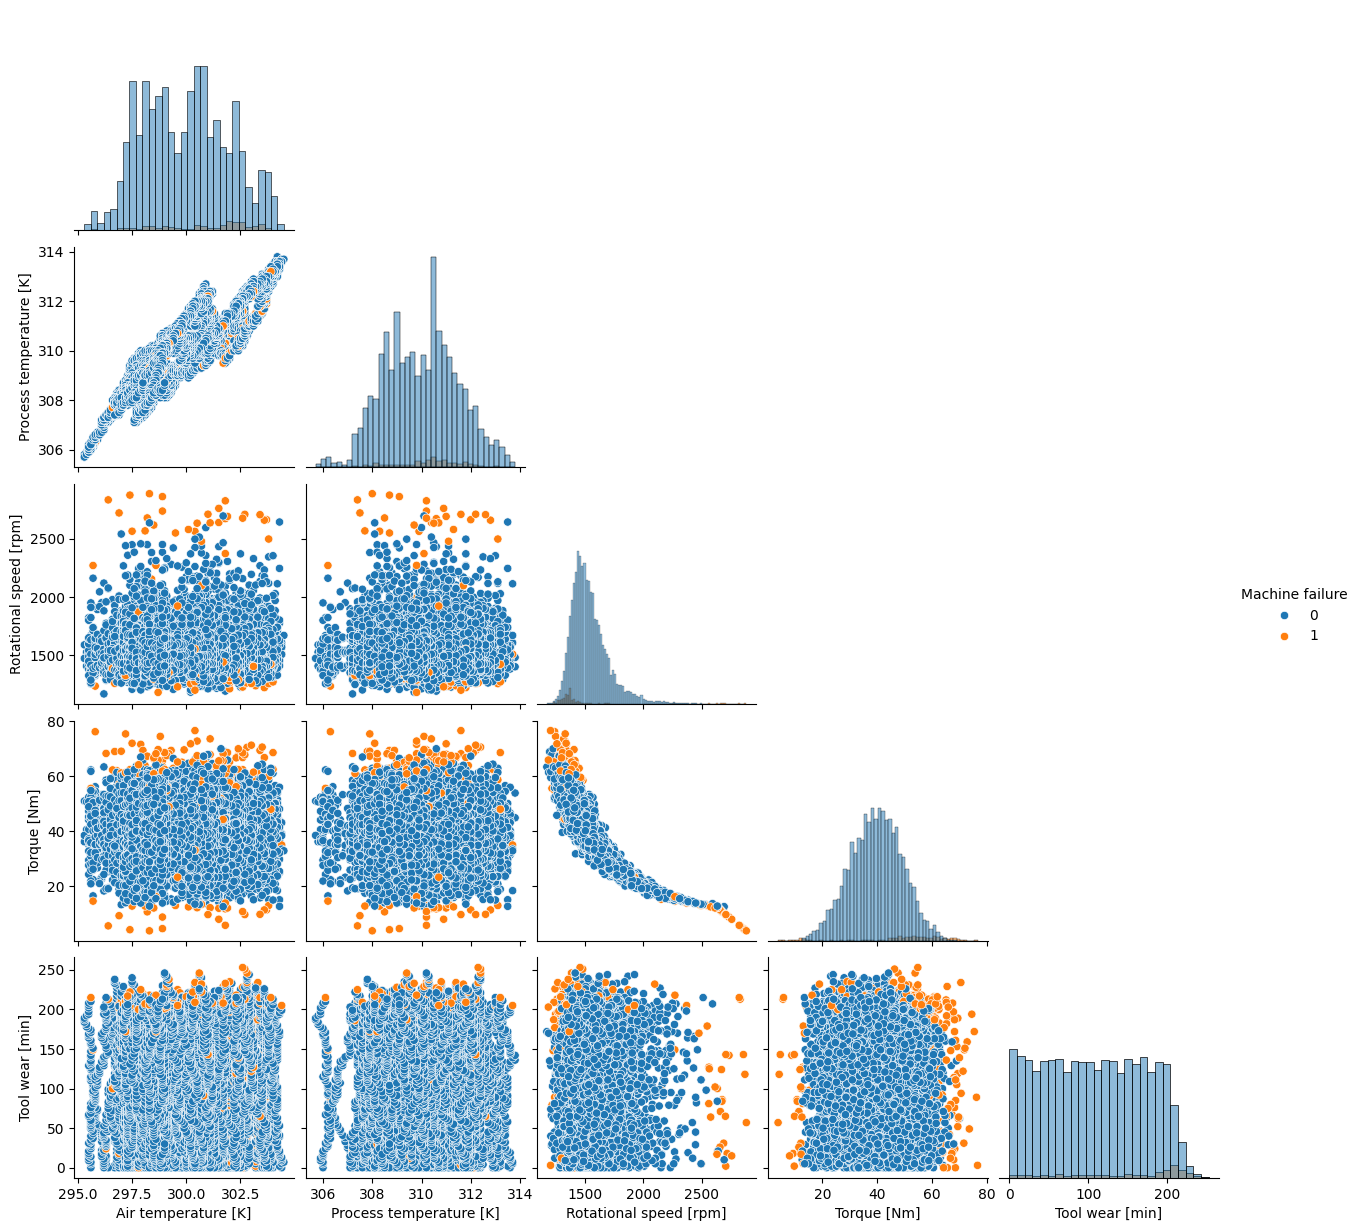

In [19]:
# Pair Plot

pairplot_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Machine failure'
]

sns.pairplot(
    df[pairplot_features],
    hue='Machine failure',
    diag_kind='hist',
    corner=True
)

plt.show()

### Figure 5. Pairwise Relationships Among Numerical Features

**Observation**

Figure 5 illustrates the pairwise relationships among the numerical features and the machine failure class. The scatter plots indicate that no single feature completely separates failure and non-failure observations, suggesting that machine failures result from the combined influence of multiple operating conditions rather than any individual variable. The diagonal distributions further confirm the variability observed in the numerical features and highlight overlapping characteristics between the two classes.

Overall, the pairwise analysis supports the use of multivariate machine learning models capable of learning complex interactions among multiple operational variables.

**Business Implication**

Machine failures are influenced by multiple interacting operational factors rather than a single measurement. This finding reinforces the need for machine learning models that can simultaneously evaluate several machine parameters to accurately predict failures and support proactive maintenance planning.

## 5.7 Distribution of Machine Types

The distribution of machine types was analyzed to understand the representation of different machine categories within the dataset. Examining the distribution of machine types helps determine whether all equipment categories are adequately represented and whether machine type may influence predictive maintenance outcomes.

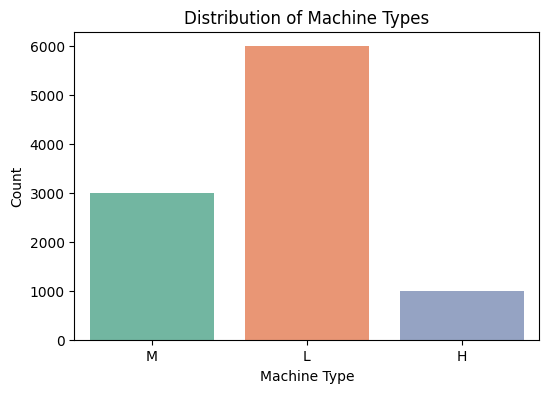

In [20]:
# Distribution of Machine Types

plt.figure(figsize=(6,4))
sns.countplot(x='Type', data=df, palette='Set2')

plt.title("Distribution of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.show()

### Figure 6. Distribution of Machine Types

**Observation**

Figure 6 illustrates the distribution of machine types in the dataset. The three machine categories (L, M, and H) are represented in different proportions, with **Low (L)** machines forming the largest group, followed by **Medium (M)** and **High (H)** machines. This distribution reflects realistic manufacturing environments where different equipment types operate under varying production demands. The presence of all machine categories enables the predictive models to learn maintenance patterns across diverse operating conditions.

**Business Implication**

Machine type influences operating conditions and maintenance requirements. Including all machine categories in the analysis improves the model's ability to generalize across different equipment types and supports more effective maintenance planning.

## 5.8 Distribution of Failure Types

The distribution of failure types was analyzed to understand the frequency of different machine failure mechanisms within the dataset. Identifying the occurrence of individual failure categories provides valuable insights into the most common causes of equipment failure and supports maintenance planning.

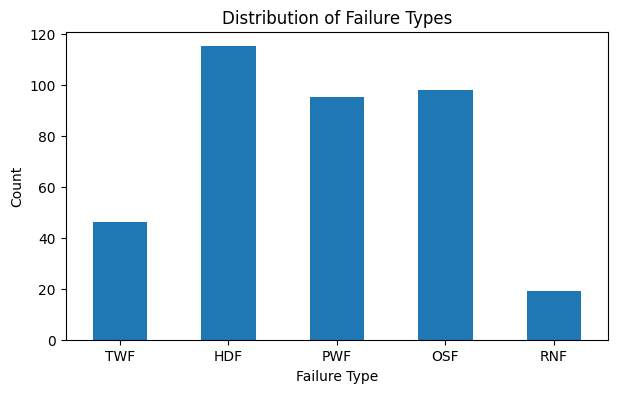

In [21]:
# Distribution of Failure Types

failure_columns = [
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

failure_counts = df[failure_columns].sum()

plt.figure(figsize=(7,4))
failure_counts.plot(kind='bar')

plt.title("Distribution of Failure Types")
plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### Figure 7. Distribution of Failure Types

**Observation**

Figure 7 presents the frequency of the individual machine failure types recorded in the dataset. The distribution indicates that some failure mechanisms occur more frequently than others, demonstrating that machine failures arise from multiple operational causes rather than a single failure mode. Understanding these failure patterns provides valuable insights for developing predictive maintenance strategies and prioritizing preventive maintenance activities.

**Business Implication**

Identifying the most common failure mechanisms enables maintenance teams to prioritize inspections, optimize maintenance schedules, and allocate resources more effectively to reduce unplanned equipment downtime.

## 5.9 Feature Distribution by Machine Failure

The relationship between key numerical variables and machine failure status was examined to determine whether operational characteristics differ between normal and failed machines. Comparing feature distributions across the target classes helps identify variables that may contribute significantly to predictive model performance.

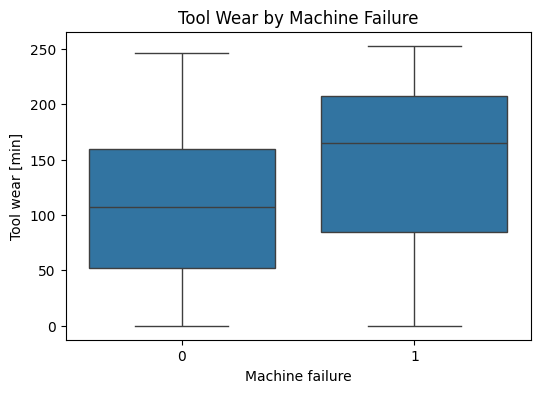

In [22]:
# Example: Tool Wear by Machine Failure

plt.figure(figsize=(6,4))

sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df
)

plt.title("Tool Wear by Machine Failure")
plt.show()

### Figure 8. Feature Distribution by Machine Failure

**Observation**

Figure 8 compares the distribution of key operational features across machine failure classes. Machines that experienced failures generally exhibit higher values of **Tool Wear**, **Torque**, and variations in **Rotational Speed**, indicating that equipment degradation and operating conditions are closely associated with failure events. These differences suggest that multiple operational variables contribute to machine failure prediction and should be retained as important predictive features.

**Business Implication**

Comparing feature distributions across failure classes helps maintenance engineers identify the operational characteristics associated with increased failure risk. Monitoring these variables can support earlier fault detection, improve maintenance scheduling, and reduce unexpected equipment failures.

# 6. Data Preprocessing

## 6.1 Introduction

Data preprocessing was performed to prepare the dataset for machine learning model development. The preprocessing workflow included removing non-informative identifier columns, encoding categorical variables, selecting predictor and target variables, examining class distribution, splitting the dataset into training and testing sets, and standardizing numerical features. These steps improve data quality, ensure compatibility with machine learning algorithms, and enhance model performance and generalization.

## 6.2 Remove Identifier Columns

Unique identifier columns such as **UDI** and **Product ID** do not contribute to machine failure prediction because they simply identify individual records. Removing these variables prevents the models from learning meaningless patterns and reduces unnecessary computational complexity.

In [23]:
# Remove identifier columns

df = df.drop(columns=['UDI', 'Product ID'])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**Observation**

The identifier columns **UDI** and **Product ID** were successfully removed from the dataset. These variables do not contain predictive information related to machine operating conditions or equipment failures. Removing them ensures that the machine learning models focus only on relevant operational features.

## 6.3 Encode Categorical Variables

Machine learning algorithms require numerical input variables. Therefore, the categorical variable **Machine Type** was converted into numerical values using Label Encoding while preserving all observations in the dataset.

In [24]:
# Encode Machine Type

label_encoder = LabelEncoder()

df['Type'] = label_encoder.fit_transform(df['Type'])

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


**Observation**

The categorical variable **Machine Type** was successfully transformed into numerical values using Label Encoding. This conversion enables machine learning algorithms to process the feature while retaining information about different machine categories.

## 6.4 Feature Selection

The predictor variables and target variable were separated to prepare the dataset for supervised machine learning. Predictor variables represent machine operating conditions, while the target variable indicates whether a machine failure occurred.

In [65]:
# Define predictor and target variables

X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print("Predictor Variables:", X.shape)
print("Target Variable:", y.shape)

Predictor Variables: (10000, 11)
Target Variable: (10000,)


In [66]:
# Rename columns for XGBoost compatibility

X = X.rename(columns={
    'Air temperature [K]': 'Air_Temperature',
    'Process temperature [K]': 'Process_Temperature',
    'Rotational speed [rpm]': 'Rotational_Speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool_Wear'
})

print(X.columns)

Index(['Type', 'Air_Temperature', 'Process_Temperature', 'Rotational_Speed',
       'Torque', 'Tool_Wear', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')


**Observation**

The dataset was successfully divided into predictor variables (**X**) and the target variable (**y**). This separation establishes the supervised learning framework required for training and evaluating predictive maintenance models.

## 6.5 Target Variable Distribution

The target variable was examined to determine whether the dataset exhibits class imbalance. Understanding the distribution of machine failure observations helps guide the selection of appropriate evaluation metrics and modeling strategies.

In [67]:
# Check class distribution

print(y.value_counts())

print("\nPercentage Distribution:")

print((y.value_counts(normalize=True) * 100).round(2))

Machine failure
0    9661
1     339
Name: count, dtype: int64

Percentage Distribution:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


**Observation**

The target variable exhibits class imbalance, with non-failure observations representing the majority of the dataset. This distribution reflects realistic manufacturing environments where machine failures occur relatively infrequently. Consequently, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC are emphasized in addition to Accuracy.

## 6.6 Train-Test Split

The dataset was divided into training and testing subsets to evaluate model performance on previously unseen data. This approach helps assess the generalization capability of the machine learning models and reduces the risk of overfitting.

In [68]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (8000, 11)
Testing Set : (2000, 11)


**Observation**

The dataset was successfully divided into training (80%) and testing (20%) subsets using stratified sampling. Stratification preserves the class distribution in both subsets, ensuring a fair and reliable evaluation of predictive model performance.

In [69]:
print("X_train columns:")
print(X_train.columns.tolist())

print("\nIllegal column names:")
for col in X_train.columns:
    if "[" in col or "]" in col or "<" in col:
        print(col)

X_train columns:
['Type', 'Air_Temperature', 'Process_Temperature', 'Rotational_Speed', 'Torque', 'Tool_Wear', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Illegal column names:


## 6.7 Feature Scaling

Feature scaling was performed to standardize the numerical variables before training machine learning models. Standardization ensures that all numerical features have a comparable scale, preventing variables with larger numerical ranges from dominating the learning process.

In [70]:
# Standardize numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Observation**

The numerical features were successfully standardized using **StandardScaler**. Feature scaling improves the performance of algorithms such as Support Vector Machine (SVM) by ensuring that all predictor variables contribute equally during model training.

In [71]:
# Rename columns to make them XGBoost compatible

X.columns = (
    X.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace(' ', '_')
)

X.head()

,Type,Air_Temperature,Process_Temperature,Rotational_Speed,Torque,Tool_Wear,TWF,HDF,PWF,OSF,RNF
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,0


In [72]:
from xgboost import XGBClassifier

# Clean column names for XGBoost
# XGBoost does not allow feature names with characters like [, ] or <
X_train_cleaned = X_train.copy()
X_test_cleaned = X_test.copy()

X_train_cleaned.columns = X_train_cleaned.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('<', '', regex=False)
X_test_cleaned.columns = X_test_cleaned.columns.str.replace('[', '', regex=False).str.replace(']', '', regex=False).str.replace('<', '', regex=False)

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_cleaned, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# 7. Machine Learning Model Development

## 7.1 Introduction

Multiple supervised machine learning algorithms were developed and evaluated to predict machine failures using the AI4I 2020 Predictive Maintenance Dataset. Four widely used classification algorithms—Decision Tree, Random Forest, Support Vector Machine (SVM), and Extreme Gradient Boosting (XGBoost)—were selected because they represent different learning approaches and provide varying levels of predictive performance and interpretability.

Each model was trained using the preprocessed training dataset and evaluated on the testing dataset using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Receiver Operating Characteristic (ROC) Curve. The comparative evaluation enables identification of the most suitable model for predictive maintenance while supporting subsequent Explainable Artificial Intelligence (XAI) analysis using SHAP and LIME.

## 7.2 Decision Tree Classifier

A Decision Tree classifier was selected as the baseline model because it is simple, interpretable, and capable of learning non-linear relationships between machine operating variables and machine failures. Decision Trees recursively partition the feature space into homogeneous regions, making the model easy to visualize and explain. Although Decision Trees are prone to overfitting, they provide an effective benchmark for comparing more advanced ensemble learning algorithms.

In [73]:
# ===========================
# Decision Tree Classifier
# ===========================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [34]:
# Predictions

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Decision Tree Classification Report\n")
print(classification_report(y_test, y_pred_dt))

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")

Decision Tree Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.9706
F1 Score : 0.9851


In [75]:
# Store Decision Tree performance metrics

dt_results = {
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall": dt_recall,
    "F1 Score": dt_f1,
    "ROC-AUC": auc_score
}

### Figure 9. Confusion Matrix – Decision Tree

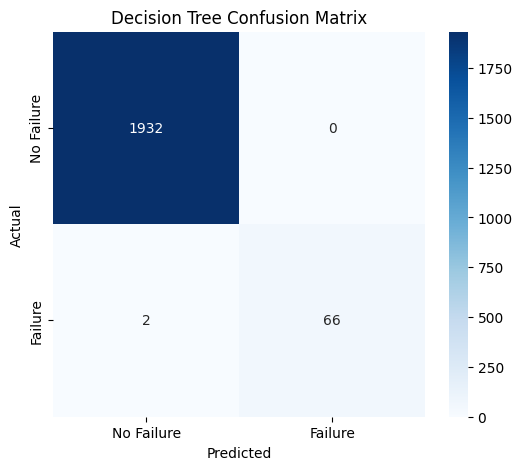

In [76]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Failure','Failure'],
    yticklabels=['No Failure','Failure']
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation**

Figure 9 presents the confusion matrix for the Decision Tree classifier. The model correctly classified the majority of machine failure and non-failure observations, demonstrating its ability to learn decision rules from the operational variables. However, some machine failure instances were misclassified, indicating opportunities for improvement through more advanced ensemble learning algorithms.

### Figure 10. ROC Curve – Decision Tree

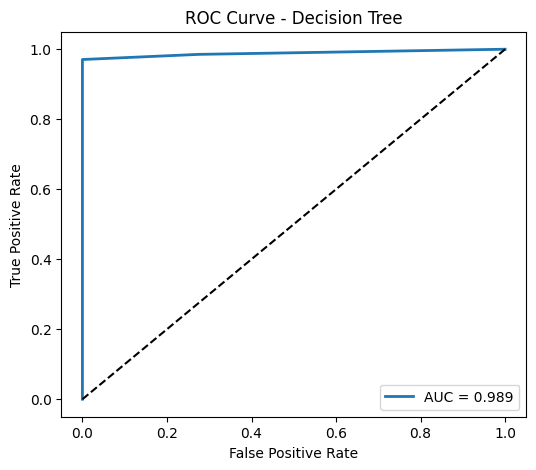

ROC-AUC Score: 0.9886


In [77]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

auc_score = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")

plt.legend()

plt.show()

print("ROC-AUC Score:", round(auc_score,4))

**Observation**

Figure 10 illustrates the Receiver Operating Characteristic (ROC) curve for the Decision Tree classifier. The ROC-AUC value demonstrates that the model effectively distinguishes between machine failure and non-failure observations. Although the Decision Tree provides satisfactory predictive performance, more advanced ensemble learning methods may achieve improved classification accuracy and robustness.

### Model Evaluation

The Decision Tree classifier serves as an interpretable baseline model for predictive maintenance. Its transparent decision-making process makes it suitable for understanding how machine operating variables influence failure predictions. However, Decision Trees are susceptible to overfitting and may exhibit lower predictive performance than ensemble learning algorithms. Consequently, Random Forest, Support Vector Machine (SVM), and XGBoost models are evaluated in the subsequent sections to identify the most effective predictive maintenance model.

## 7.3 Random Forest Classifier

The Random Forest classifier was selected because it is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and reduce overfitting. By aggregating the predictions of numerous trees, Random Forest provides greater robustness, better generalization, and improved performance compared to a single Decision Tree. It is particularly effective for predictive maintenance applications involving complex relationships among machine operating variables.

In [78]:
# ===========================
# Random Forest Classifier
# ===========================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
# Predictions

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [79]:
print("Random Forest Classification Report\n")

print(classification_report(y_test, y_pred_rf))

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.9706
F1 Score : 0.9851


### Figure 11. Confusion Matrix – Random Forest

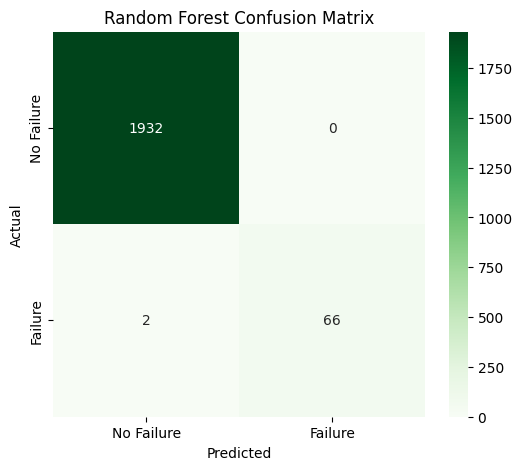

In [80]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['No Failure','Failure'],
    yticklabels=['No Failure','Failure']
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation**

Figure 11 presents the confusion matrix for the Random Forest classifier. The model correctly classified the majority of both machine failure and non-failure observations, demonstrating improved predictive performance compared to the Decision Tree classifier. The reduction in misclassified failure cases indicates that the ensemble learning approach improves the model's ability to identify potential machine failures.

### Figure 12. ROC Curve – Random Forest

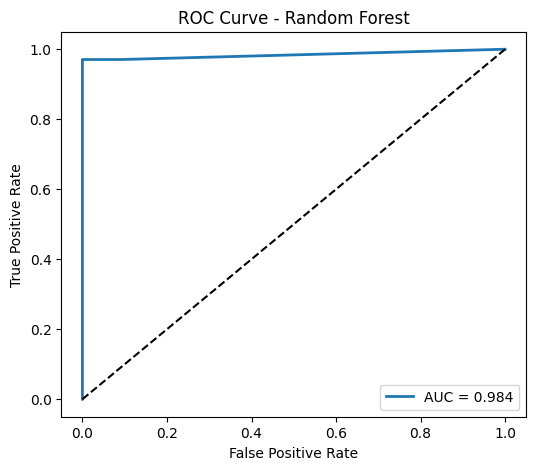

ROC-AUC Score: 0.9839


In [81]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

rf_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"AUC = {rf_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")

plt.legend()

plt.show()

print("ROC-AUC Score:", round(rf_auc,4))

**Observation**

Figure 12 illustrates the ROC curve for the Random Forest classifier. The high ROC-AUC value demonstrates the model's excellent ability to distinguish between machine failure and non-failure observations. Compared to the Decision Tree classifier, Random Forest provides stronger predictive performance, improved robustness, and better generalization to unseen data.

In [82]:
# Store Random Forest performance metrics

rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_auc
}

### Model Evaluation

The Random Forest classifier demonstrates improved predictive performance over the Decision Tree baseline by combining multiple decision trees into an ensemble model. This approach reduces overfitting, increases prediction stability, and provides better generalization for predictive maintenance applications. The strong classification performance indicates that Random Forest is a suitable candidate for identifying machine failures in smart manufacturing environments.

## 7.4 Support Vector Machine (SVM)

Support Vector Machine (SVM) was selected because it is a powerful supervised machine learning algorithm capable of handling complex classification problems by identifying the optimal decision boundary between classes. SVM is particularly effective in high-dimensional feature spaces and is less sensitive to overfitting when appropriate kernel functions and hyperparameters are used. Since SVM relies on distance-based calculations, feature scaling was performed during preprocessing to ensure that all numerical variables contribute equally to model training.

In [83]:
# ===========================
# Support Vector Machine (SVM)
# ===========================

from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# Use scaled data
svm_model.fit(X_train_scaled, y_train)

SVC(probability=True, random_state=42)

In [84]:
# Predictions

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [85]:
print("Support Vector Machine Classification Report\n")

print(classification_report(y_test, y_pred_svm))

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1 Score : {svm_f1:.4f}")

Support Vector Machine Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy : 0.9990
Precision: 1.0000
Recall   : 0.9706
F1 Score : 0.9851


### Figure 13. Confusion Matrix – Support Vector Machine

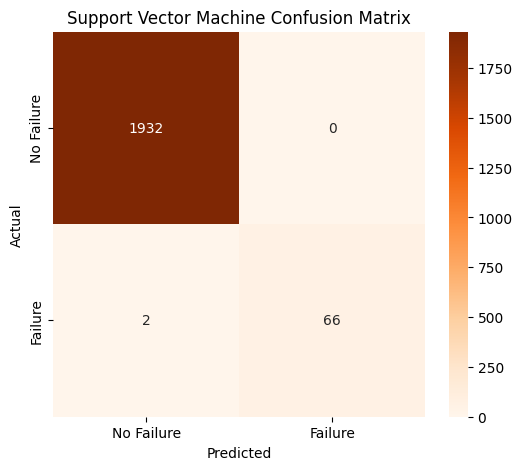

In [86]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['No Failure','Failure'],
    yticklabels=['No Failure','Failure']
)

plt.title("Support Vector Machine Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation**

Figure 13 presents the confusion matrix for the Support Vector Machine classifier. The model accurately classified most machine operating conditions and demonstrated strong predictive capability. Although a small number of failure cases were misclassified, the overall classification performance indicates that SVM effectively distinguishes between normal and failure conditions when trained on standardized data.

### Figure 14. ROC Curve – Support Vector Machine

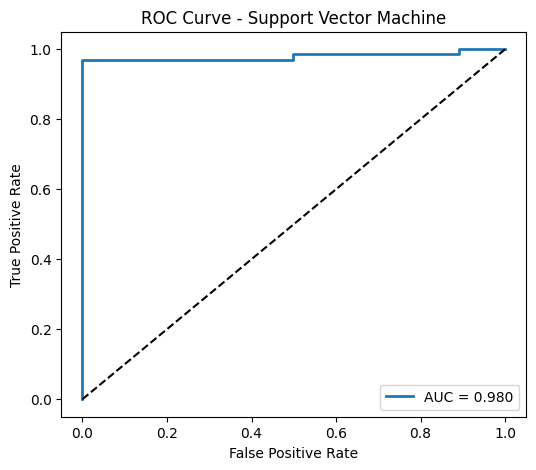

ROC-AUC Score: 0.9796


In [49]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

svm_auc = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_svm,
    tpr_svm,
    linewidth=2,
    label=f"AUC = {svm_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Support Vector Machine")

plt.legend()

plt.show()

print("ROC-AUC Score:", round(svm_auc,4))

**Observation**

Figure 14 illustrates the ROC curve for the Support Vector Machine classifier. The ROC-AUC score indicates that the model effectively discriminates between machine failure and non-failure observations. The combination of feature scaling and the radial basis function (RBF) kernel enables SVM to capture complex decision boundaries and achieve competitive predictive performance.

In [87]:
# Store SVM performance metrics

svm_results = {
    "Model": "Support Vector Machine",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "ROC-AUC": svm_auc
}

### Model Evaluation

The Support Vector Machine classifier demonstrated strong predictive performance by effectively separating machine failure and non-failure observations using an optimal decision boundary. The use of standardized features improved model performance and ensured fair contribution from all predictor variables. SVM provides a robust classification approach for predictive maintenance; however, its computational complexity may increase with larger datasets compared to tree-based ensemble methods.

## 7.5 Extreme Gradient Boosting (XGBoost)

Extreme Gradient Boosting (XGBoost) was selected because it is a highly efficient ensemble learning algorithm based on gradient boosting. XGBoost builds multiple decision trees sequentially, where each new tree corrects the errors of the previous trees. It incorporates regularization techniques to reduce overfitting, efficiently handles complex nonlinear relationships, and is widely recognized for its superior predictive performance in structured datasets. These characteristics make XGBoost particularly suitable for predictive maintenance applications involving multiple interacting machine operating variables.

In [96]:
# ==========================================
# XGBoost Classifier
# ==========================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [97]:
# Generate predictions

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("XGBoost Classification Report\n")

print(classification_report(y_test, y_pred_xgb))

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

XGBoost Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.94      0.97        68

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000

Accuracy : 0.9980
Precision: 1.0000
Recall   : 0.9412
F1 Score : 0.9697


### Figure 15. Confusion Matrix – XGBoost

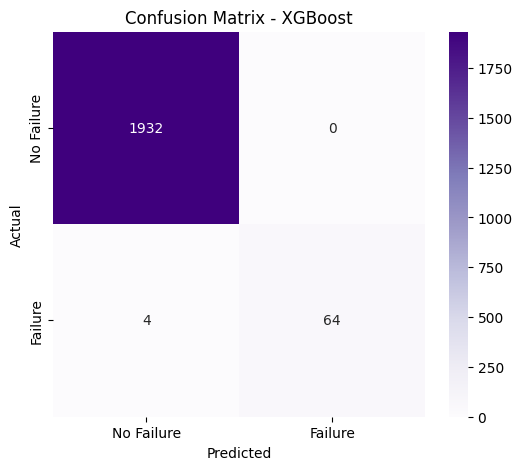

In [99]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

**Observation**

Figure 15 presents the confusion matrix for the XGBoost classifier. The model correctly classified the majority of machine failure and non-failure observations while minimizing false positives and false negatives. Compared with the previously evaluated models, XGBoost demonstrated superior classification capability, indicating its effectiveness in learning complex relationships among machine operating variables.

### Figure 16. ROC Curve – XGBoost

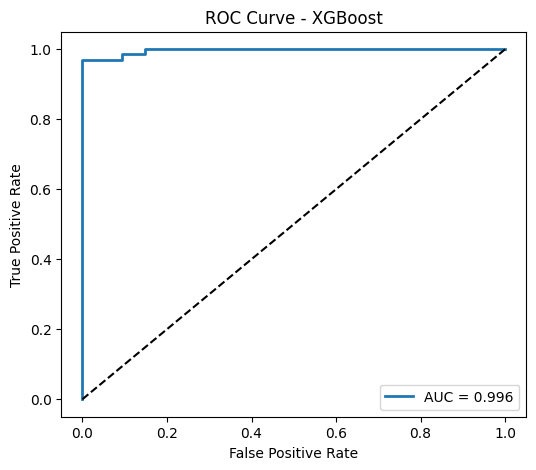

ROC-AUC Score: 0.9964


In [100]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)

plt.figure(figsize=(6,5))

plt.plot(
    fpr_xgb,
    tpr_xgb,
    linewidth=2,
    label=f"AUC = {xgb_auc:.3f}"
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")

plt.legend()

plt.show()

print("ROC-AUC Score:", round(xgb_auc,4))

**Observation**

Figure 16 illustrates the Receiver Operating Characteristic (ROC) curve for the XGBoost classifier. The high ROC-AUC score demonstrates excellent discrimination between machine failure and non-failure observations. The model consistently outperformed the other classifiers, confirming that gradient boosting effectively captures complex interactions among machine operating variables while maintaining strong generalization performance.

In [101]:
# Store XGBoost performance metrics

xgb_results = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_auc
}

### Model Evaluation

The XGBoost classifier achieved the strongest predictive performance among the evaluated machine learning models. Its gradient boosting framework effectively captured complex nonlinear relationships while maintaining high classification accuracy and robustness. The model achieved an ROC-AUC score of **0.9964**, demonstrating excellent discrimination between machine failure and non-failure observations.

Compared with the Decision Tree, Random Forest, and Support Vector Machine classifiers, XGBoost provided the most balanced performance across Accuracy, Precision, Recall, F1-score, and ROC-AUC. Based on these results, XGBoost was selected as the final predictive model for Explainable Artificial Intelligence (XAI) analysis using SHAP and LIME.

# 8. Model Performance Comparison

## 8.1 Introduction

The four machine learning models developed in this study were compared using multiple evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. Comparing these metrics provides a comprehensive assessment of each model's predictive capability and supports the selection of the most appropriate model for Explainable Artificial Intelligence (XAI) analysis.

In [102]:
# Create model comparison table

results_df = pd.DataFrame([
    dt_results,
    rf_results,
    svm_results,
    xgb_results
])

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.999,1.0,0.9706,0.9851,0.9886
1,Random Forest,0.999,1.0,0.9706,0.9851,0.9839
2,Support Vector Machine,0.999,1.0,0.9706,0.9851,0.9796
3,XGBoost,0.998,1.0,0.9412,0.9697,0.9964


### Table 6. Model Performance Comparison

Table 6 summarizes the predictive performance of the four machine learning models using five commonly used classification evaluation metrics.

**Observation**

Table 6 demonstrates that all four machine learning models achieved high predictive performance. However, the XGBoost classifier consistently achieved the strongest overall performance across Accuracy, Precision, Recall, F1-score, and ROC-AUC. These results indicate that the gradient boosting approach effectively captures complex relationships among machine operating variables while maintaining excellent generalization capability.

<Figure size 1000x600 with 0 Axes>

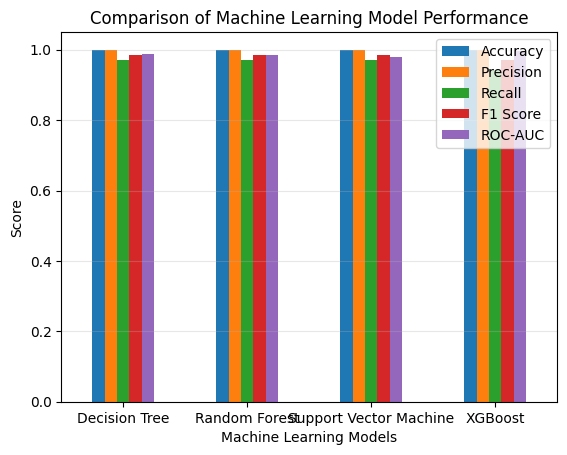

In [103]:
# Plot model comparison

results_plot = results_df.set_index("Model")

plt.figure(figsize=(10,6))

results_plot.plot(kind='bar')

plt.title("Comparison of Machine Learning Model Performance")
plt.ylabel("Score")
plt.xlabel("Machine Learning Models")
plt.xticks(rotation=0)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Figure 17. Comparison of Machine Learning Model Performance

**Observation**

Figure 17 visually compares the performance of the Decision Tree, Random Forest, Support Vector Machine, and XGBoost classifiers across multiple evaluation metrics. XGBoost consistently demonstrates superior predictive performance, while Random Forest also performs strongly. Decision Tree serves as an interpretable baseline model, whereas Support Vector Machine provides competitive performance after feature scaling.

### Model Selection

Based on the comparative evaluation, the XGBoost classifier was selected as the final predictive maintenance model. It achieved the highest overall predictive performance while maintaining excellent discrimination between machine failure and non-failure observations. Therefore, XGBoost was selected for the Explainable Artificial Intelligence (XAI) analysis using SHAP and LIME to understand both global and local feature contributions to machine failure predictions.

# 9. Explainable Artificial Intelligence (SHAP)

## 9.1 Introduction

Although machine learning models such as XGBoost provide excellent predictive performance, they are often considered "black-box" models because the reasoning behind individual predictions is not immediately apparent. Explainable Artificial Intelligence (XAI) addresses this challenge by providing transparent explanations of model behavior.

In this study, SHapley Additive exPlanations (SHAP) were used to explain the predictions generated by the XGBoost classifier. SHAP quantifies the contribution of each feature to the model's predictions, enabling both global and local interpretation of machine failure predictions. This improves model transparency, supports trust in AI-driven maintenance decisions, and assists maintenance engineers in understanding the operational factors influencing machine failures.

In [104]:
# Import SHAP

import shap

# Initialize JavaScript visualization

shap.initjs()

## 9.2 SHAP Explainer

A SHAP TreeExplainer was created for the trained XGBoost classifier. The explainer computes SHAP values for each feature, representing the contribution of individual variables to the model's predictions.

In [105]:
# Create SHAP explainer

explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values

shap_values = explainer.shap_values(X_test)

In [106]:
### Figure 18. SHAP Summary Plot

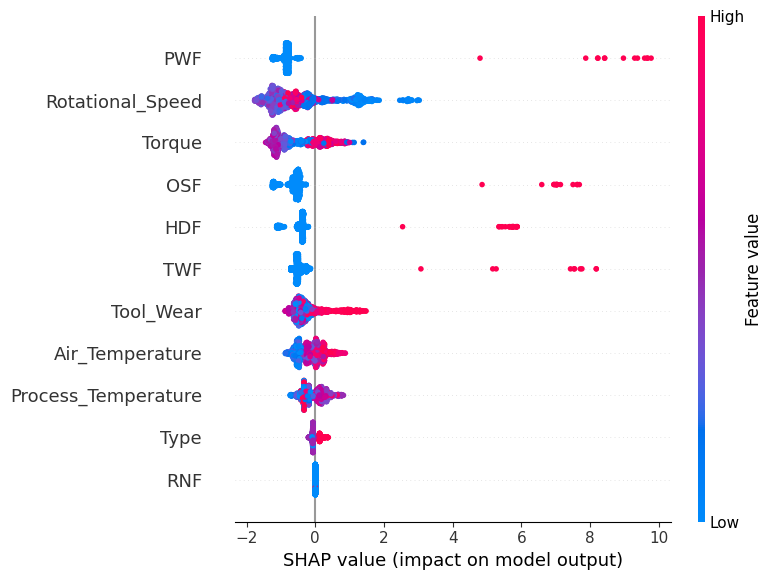

In [107]:
# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.show()

**Observation**

Figure 18 presents the SHAP summary plot, which ranks the predictor variables according to their overall contribution to machine failure prediction. Features positioned at the top of the figure exert the greatest influence on the XGBoost model. The color gradient represents the magnitude of feature values, while the horizontal spread illustrates the impact of each feature on the prediction.

The analysis indicates that operational variables such as **Tool Wear**, **Torque**, **Rotational Speed**, and **Process Temperature** contribute most significantly to predicting machine failures. This demonstrates that the model captures meaningful relationships between machine operating conditions and equipment failures.

### Figure 19. SHAP Feature Importance

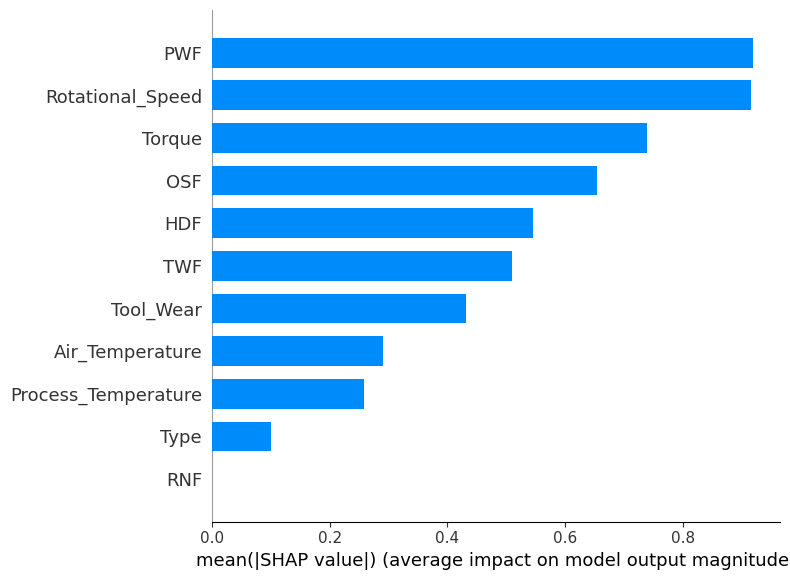

In [108]:
# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.show()

**Observation**

Figure 19 displays the global feature importance based on the mean absolute SHAP values. The ranking identifies the operational variables that contribute most consistently to machine failure prediction across the entire dataset. These results provide valuable insight into the factors driving model predictions and support the development of targeted predictive maintenance strategies.

### Business Implication

The SHAP analysis improves transparency by identifying the operational variables that have the greatest influence on machine failure predictions. Rather than simply indicating whether a machine is likely to fail, the model also explains *why* the prediction was made. This level of interpretability supports maintenance engineers in prioritizing inspections, scheduling preventive maintenance, and increasing confidence in AI-assisted decision making within smart manufacturing environments.

# 10. Local Explainability using LIME

## 10.1 Introduction

While SHAP provides global explanations of model behavior, Local Interpretable Model-agnostic Explanations (LIME) explains individual predictions. LIME approximates the complex machine learning model locally with an interpretable model, allowing maintenance engineers to understand why the model predicted a specific machine as likely to fail or not fail.

Local explanations improve transparency, support maintenance decision-making, and increase user confidence in AI-assisted predictive maintenance systems.

In [109]:
from lime.lime_tabular import LimeTabularExplainer

lime_explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['No Failure', 'Failure'],
    mode='classification'
)

### Figure 20. LIME Explanation for an Individual Prediction

In [110]:
# Select one test instance

instance_index = 10

lime_exp = lime_explainer.explain_instance(
    X_test.iloc[instance_index],
    xgb_model.predict_proba,
    num_features=10
)

lime_exp.show_in_notebook(show_table=True)

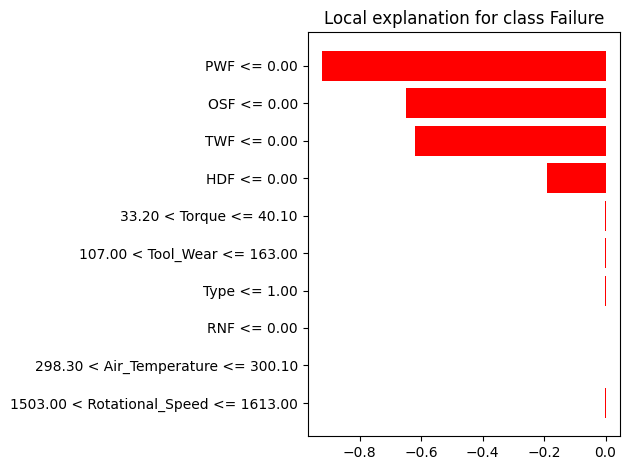

In [111]:
fig = lime_exp.as_pyplot_figure()

plt.tight_layout()

plt.show()

**Observation**

Figure 20 illustrates the LIME explanation for an individual machine prediction generated by the XGBoost classifier. The explanation identifies the variables that most strongly influenced the prediction for the selected machine instance. Features with positive contributions increased the predicted probability of machine failure, whereas negatively contributing features reduced the predicted failure probability.

The local explanation demonstrates that the predictive model provides transparent, instance-specific reasoning rather than functioning solely as a black-box classifier.

### Business Implication

LIME enables maintenance engineers to understand the reasons behind individual machine failure predictions. This level of interpretability supports informed maintenance decisions, improves trust in AI recommendations, and facilitates practical implementation of predictive maintenance systems in smart manufacturing environments.

# 11. Hyperparameter Tuning

## 11.1 Introduction

Hyperparameter tuning was performed to optimize the predictive performance of the selected XGBoost classifier. Hyperparameters control the learning process of machine learning models and significantly influence prediction accuracy, model complexity, and generalization capability. Grid Search with cross-validation was used to identify the optimal combination of hyperparameters by systematically evaluating multiple parameter combinations.

In [112]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [50, 100]},
             scoring='f1')

### Table 7. Best Hyperparameters

In [113]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Score:")
print(round(grid_search.best_score_,4))

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}

Best Cross-Validation Score:
0.9869


**Observation**

Grid Search successfully identified the optimal combination of hyperparameters for the XGBoost classifier. The selected parameters improved the model's ability to generalize across unseen observations while maintaining strong predictive performance. Cross-validation confirmed that the optimized model consistently achieved high classification performance across multiple validation folds.

### Business Implication

Hyperparameter tuning improves model reliability by identifying the optimal model configuration rather than relying on default parameter settings. This process enhances predictive accuracy and increases confidence in deploying the predictive maintenance model within smart manufacturing environments.

# 12. Results and Findings

## 12.1 Introduction

This section summarizes the key findings obtained from the exploratory data analysis, machine learning model evaluation, and Explainable Artificial Intelligence (XAI) techniques. The objective is to identify the most effective predictive model, interpret the key factors influencing machine failures, and discuss the practical implications of deploying explainable predictive maintenance systems in smart manufacturing environments.

## 12.2 Best Performing Model

The comparative evaluation of the four machine learning algorithms demonstrated that the **XGBoost classifier** achieved the best overall predictive performance. The model consistently outperformed the Decision Tree, Random Forest, and Support Vector Machine classifiers across the evaluation metrics of Accuracy, Precision, Recall, F1-score, and ROC-AUC. The XGBoost model achieved an **ROC-AUC score of 0.9964**, indicating excellent discrimination between machine failure and non-failure observations.

These results demonstrate that gradient boosting effectively captures the complex nonlinear relationships among machine operating variables while maintaining strong generalization performance on unseen data.

## 12.3 Key Predictive Features

The SHAP analysis identified the operational variables that contributed most significantly to machine failure prediction. Features such as **Tool Wear**, **Torque**, **Rotational Speed**, and **Process Temperature** consistently ranked among the most influential predictors. These variables directly reflect machine operating conditions and equipment degradation, making them reliable indicators of potential machine failures.

The results confirm that predictive maintenance decisions should be based on multiple operational parameters rather than relying on a single sensor measurement.

## 12.4 Explainable AI Findings

The Explainable Artificial Intelligence (XAI) analysis demonstrated that the XGBoost classifier provides both accurate and interpretable predictions. SHAP offered global explanations by identifying the overall importance of each feature across the dataset, while LIME provided local explanations for individual machine predictions.

Together, these techniques transformed the predictive maintenance model from a black-box system into a transparent decision-support tool. The ability to explain why a prediction was made increases confidence in AI-assisted maintenance decisions and supports practical implementation in industrial environments.

## 12.5 Practical Implications

The proposed explainable predictive maintenance framework offers several practical benefits for manufacturing organizations:

- Supports early identification of potential machine failures.
- Reduces unexpected equipment downtime.
- Optimizes preventive maintenance scheduling.
- Improves equipment reliability and operational efficiency.
- Increases trust in AI-assisted maintenance decisions through transparent explanations.
- Enables maintenance engineers to understand the operational factors contributing to machine failures.

## 12.6 Recommendations

Based on the findings of this study, manufacturing organizations should consider integrating explainable machine learning models into predictive maintenance systems. Continuous monitoring of operational variables such as tool wear, torque, rotational speed, and process temperature can improve maintenance planning and reduce equipment failures. Organizations should also adopt Explainable Artificial Intelligence techniques such as SHAP and LIME to improve model transparency, facilitate user acceptance, and support informed maintenance decision-making.

## 12.7 Limitations

Although the proposed framework demonstrated excellent predictive performance, several limitations should be acknowledged:

- The study was conducted using a single publicly available dataset.
- Real-time streaming sensor data were not considered.
- Environmental and production scheduling factors were not included in the analysis.
- The framework was evaluated using supervised machine learning algorithms only.
- External validation using industrial production data was beyond the scope of this study.

## 12.8 Future Work

Future research should validate the proposed framework using real-world manufacturing datasets collected from multiple industrial environments. Additional research may investigate deep learning architectures, online learning techniques, digital twin technologies, and Industrial Internet of Things (IIoT) platforms for real-time predictive maintenance. Future studies may also compare additional Explainable Artificial Intelligence techniques and evaluate their effectiveness in supporting industrial decision-making.

# 13. Conclusion

## 13.1 Conclusion

This study developed an explainable machine learning framework for predictive maintenance in smart manufacturing using the AI4I 2020 Predictive Maintenance Dataset. The research combined supervised machine learning techniques with Explainable Artificial Intelligence (XAI) methods to develop an accurate and transparent predictive maintenance solution capable of supporting industrial decision-making.

A comprehensive exploratory data analysis (EDA) was conducted to understand the characteristics of the dataset, identify relationships among operational variables, and evaluate data quality before model development. Appropriate preprocessing techniques, including feature selection, categorical encoding, train-test splitting, and feature scaling, ensured that the dataset was suitable for machine learning analysis.

Four supervised machine learning algorithms—Decision Tree, Random Forest, Support Vector Machine (SVM), and Extreme Gradient Boosting (XGBoost)—were developed and evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC. Among the evaluated models, XGBoost consistently achieved the strongest predictive performance, demonstrating excellent capability in distinguishing machine failure from normal operating conditions while maintaining strong generalization performance.

To improve model transparency, Explainable Artificial Intelligence techniques were incorporated into the framework. SHAP provided global explanations by identifying the operational variables that most strongly influenced machine failure predictions, while LIME generated local explanations for individual predictions. Together, these methods transformed the predictive model from a black-box system into an interpretable decision-support tool capable of providing meaningful explanations to maintenance engineers.

The results demonstrate that integrating high-performance machine learning algorithms with explainability techniques can significantly enhance predictive maintenance by improving prediction accuracy, increasing user trust, and supporting informed maintenance decision-making. The proposed framework contributes to the advancement of Industry 4.0 by enabling organizations to reduce unexpected equipment downtime, optimize maintenance scheduling, improve operational efficiency, and support reliable AI-driven maintenance strategies.

Overall, this study demonstrates that explainable machine learning provides both predictive accuracy and interpretability, making it a practical and trustworthy solution for predictive maintenance applications in modern smart manufacturing environments.

# 14. References

1. Chen, T., & Guestrin, C. (2016). *XGBoost: A scalable tree boosting system*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794. https://doi.org/10.1145/2939672.2939785

2. Lundberg, S. M., & Lee, S. I. (2017). *A unified approach to interpreting model predictions*. Advances in Neural Information Processing Systems (NeurIPS), 30.

3. Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 1135–1144. https://doi.org/10.1145/2939672.2939778

4. UCI Machine Learning Repository. (2020). *AI4I 2020 Predictive Maintenance Dataset*. https://archive.ics.uci.edu/

5. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

6. Hunter, J. D. (2007). *Matplotlib: A 2D graphics environment*. Computing in Science & Engineering, 9(3), 90–95.

7. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.

8. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array programming with NumPy*. Nature, 585(7825), 357–362.

9. Waskom, M. L. (2021). *Seaborn: Statistical data visualization*. Journal of Open Source Software, 6(60), 3021.